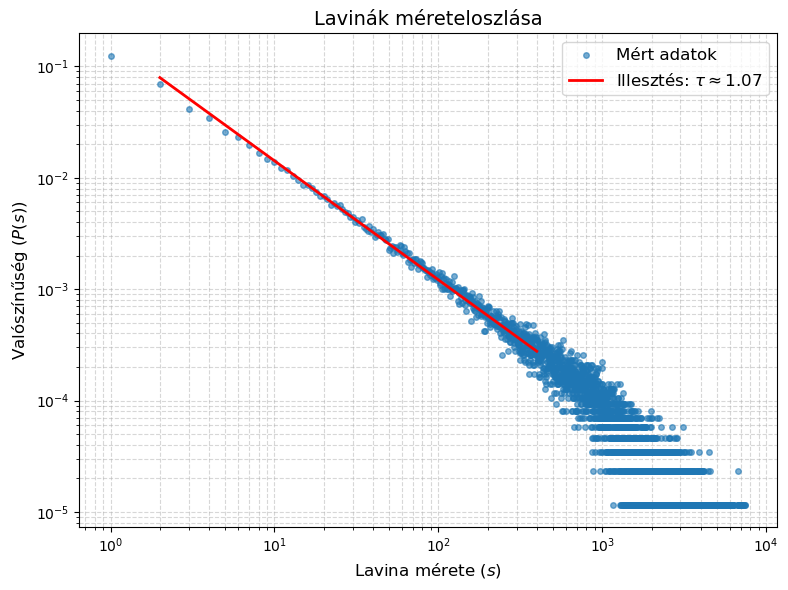

A skálázási törvény kitevője (tau) kb: 1.07


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data = np.loadtxt("datas/sandpile.data", skiprows = 1)
    sizes = data[:, 0]
    counts = data[:, 1]
    
    prob = counts / np.sum(counts)

    mask = (sizes > 1) & (sizes < 400)
    log_s = np.log10(sizes[mask])
    log_p = np.log10(prob[mask])
    
    slope, intercept = np.polyfit(log_s, log_p, 1)
    tau = -slope

    plt.figure(figsize = (8, 6))
    plt.loglog(sizes, prob, "o", markersize = 4, alpha = 0.6, label = "Mért adatok")
    plt.loglog(sizes[mask], 10**(intercept + slope * np.log10(sizes[mask])), 
               "r-", linewidth = 2, label = f"Illesztés: $\\tau \\approx {tau:.2f}$")

    plt.title("Lavinák méreteloszlása", fontsize = 14)
    plt.xlabel("Lavina mérete ($s$)", fontsize = 12)
    plt.ylabel("Valószínűség ($P(s)$)", fontsize = 12)
    plt.legend(fontsize = 12)
    plt.grid(True, which = "both", ls = "--", alpha = 0.5)
    
    plt.tight_layout()
    plt.savefig("sandpile_scaling.pdf")
    plt.show()
    
    print(f"A skálázási törvény kitevője (tau) kb: {tau:.2f}")

except OSError:
    print("Hiba: datas/sandpile.data nem található!")

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
C:\Users\krucs\AppData\Local\Temp\ipykernel_6192\1953088019.py:28: SyntaxWarning: invalid escape sequence '\l'
  axs[i].set_xlabel("$\log(1/s)$", fontsize = 12)
C:\Users\krucs\AppData\Local\Temp\ipykernel_6192\1953088019.py:29: SyntaxWarning: invalid escape sequence '\l'
  axs[i].set_ylabel("$\log(N)$", fontsize = 12)


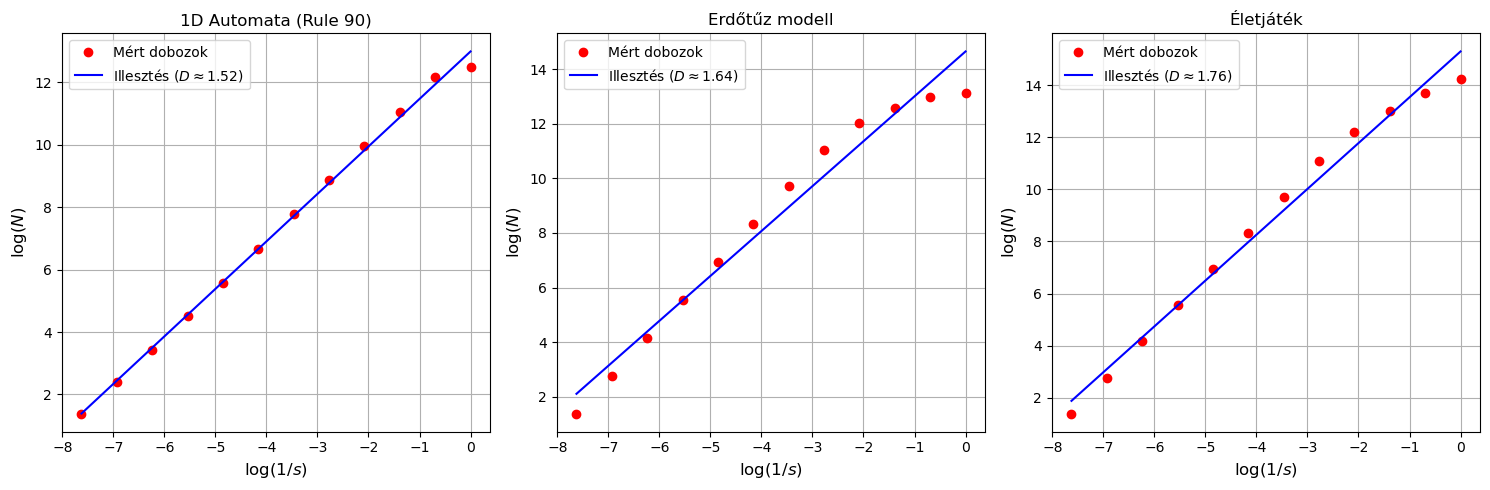

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    ("datas/box_1d.data", "1D automata (rule 90)"),
    ("datas/box_forest.data", "Erdőtűz modell"),
    ("datas/box_gol.data", "Életjáték")
]

fig, axs = plt.subplots(1, 3, figsize = (15, 5))

for i, (filename, title) in enumerate(files):
    try:
        data = np.loadtxt(filename, skiprows = 1)
        s = data[:, 0]
        N = data[:, 1]
        
        log_inv_s = np.log(1.0 / s)
        log_N = np.log(N)
        
        coeffs = np.polyfit(log_inv_s, log_N, 1)
        D = coeffs[0]
        
        axs[i].plot(log_inv_s, log_N, "ro", label = "Mért dobozok")
        axs[i].plot(log_inv_s, np.polyval(coeffs, log_inv_s), "b-", label = f"Illesztés ($D \\approx {D:.2f}$)")
        
        axs[i].set_title(title, fontsize = 12)
        axs[i].set_xlabel("$\log(1/s)$", fontsize = 12)
        axs[i].set_ylabel("$\log(N)$", fontsize = 12)
        axs[i].legend()
        axs[i].grid(True)
        
    except OSError:
        print(f"Hiba: A {filename} nem található! Futtasd le előbb a C++ kódot.")

plt.tight_layout()
plt.savefig("fractal_dimensions_cpp.pdf")
plt.show()